In [ ]:
import numpy as np
import pandas as pd
from zipfile import ZipFile
import os

In [ ]:
aisles = pd.read_csv('/content/drive/MyDrive/data/instacart-market-basket-analysis/aisles.csv')
departments = pd.read_csv('/content/drive/MyDrive/data/instacart-market-basket-analysis/departments.csv')
order_products_prior = pd.read_csv('/content/drive/MyDrive/data/instacart-market-basket-analysis/order_products__prior.csv')
order_products_train = pd.read_csv('/content/drive/MyDrive/data/instacart-market-basket-analysis/order_products__train.csv')
orders = pd.read_csv('/content/drive/MyDrive/data/instacart-market-basket-analysis/orders.csv')
products = pd.read_csv('/content/drive/MyDrive/data/instacart-market-basket-analysis/products.csv')
sample_submission = pd.read_csv('/content/drive/MyDrive/data/instacart-market-basket-analysis/sample_submission.csv')

# Simple Exploration Notebook - Instacart

In this notebook, we will try and explore the basic information about the dataset given. The dataset for this competition is a relational set of files describing customers' orders over time.

### Objective:

The goal of the competition is to predict which products will be in a user's next order. The dataset is anonymized and contains a sample of over 3 million grocery orders from more than 200,000 Instacart users. 

For each user, 4 and 100 of their orders are given, with the sequence of products purchased in each order.

Let us start by importing the necessary modules.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
color = sns.color_palette()

Let us list out the files that are present in this competition.!

Before we dive deep into the exploratory analysis, let us know a little more about the files given. To understand it better, let us first read all the files as dataframe objects and then look at the top few rows.

## Orders

유저 별로 모든 주문이 순서대로 기록되어 있다. 

columns : 
- order_id : 주문 번호
- user_id : 유저
- eval_set : 'prior', 'train', 'test' 해당 주문이 어떤 데이터인지.
    - prior : 이전 모든 주문
    - train, test : 가장 마지막 주문. train은 주문의 정보가 있고, test는 우리가 맞춰야 한다.

- order_number : 해당 주문이 몇 번째 주문인지. 
- order_dow : 주문일이 무슨 요일인지.
- order_hour_of_day : 몇시에 주문 했는지.
- days_since_prior_order : 이전 주문과의 차이 일수.

총 3,421,083 건의 주문이 있다.



In [ ]:
orders.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [ ]:
orders[orders['eval_set'] == 'test']

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
38,2774568,3,test,13,5,15,11.0
44,329954,4,test,6,3,12,30.0
53,1528013,6,test,4,3,16,22.0
96,1376945,11,test,8,6,11,8.0
102,1356845,12,test,6,1,20,30.0
...,...,...,...,...,...,...,...
3420918,2728930,206202,test,23,2,17,6.0
3420929,350108,206204,test,5,4,14,14.0
3421001,1043943,206206,test,68,0,20,0.0
3421018,2821651,206207,test,17,2,13,14.0


## Order_products_prior

주문 번호 별로 어떤 제품을 주문했는지에 대한 정보.

colums :
- order_id : 주문 번호.
- product_id : 상품 번호.
- add_to_cart_order : 제품이 장바구니에 담긴 순서
- reordered : 재주문 여부. (1과 0으로 표시)

In [ ]:
order_products_prior.head()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


## Order_products_train

가장 마지막 주문 정보

In [ ]:
order_products_train.head()

,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1


As we could see, orders.csv has all the information about the given order id like the user who has purchased the order, when was it purchased, days since prior order and so on.

The columns present in order_products_train and order_products_prior are same. Then what is the difference between these files?

As mentioned earlier, in this dataset, 4 to 100 orders of a customer are given (we will look at this later) and we need to predict the products that will be re-ordered. So the last order of the user has been taken out and divided into train and test sets. All the prior order informations of the customer are present in order_products_prior file. We can also note that there is a column in orders.csv file called eval_set which tells us as to which of the three datasets (prior, train or test) the given row goes to. 

Order_products*csv file has more detalied information about the products that been bought in the given order along with the re-orderd status. 

Let us first get the count of rows in each of the three sets.

In [ ]:
sample_submission.head()

,order_id,products
0,17,39276 29259
1,34,39276 29259
2,137,39276 29259
3,182,39276 29259
4,257,39276 29259


In [ ]:
products.tail()

,product_id,product_name,aisle_id,department_id
49683,49684,"Vodka, Triple Distilled, Twist of Vanilla",124,5
49684,49685,En Croute Roast Hazelnut Cranberry,42,1
49685,49686,Artisan Baguette,112,3
49686,49687,Smartblend Healthy Metabolism Dry Cat Food,41,8
49687,49688,Fresh Foaming Cleanser,73,11


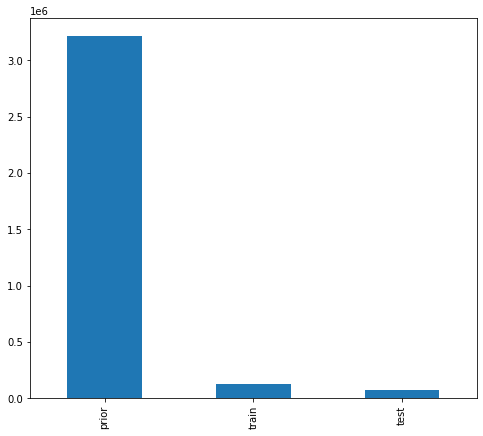

In [ ]:
# 대부분의 데이터는 prior이다. 
plt.figure(figsize=(8, 7))
orders['eval_set'].value_counts().plot.bar()
plt.show()

In [ ]:
# train, test 확인
orders.groupby('eval_set')['user_id'].nunique()

eval_set
prior    206209
test      75000
train    131209
Name: user_id, dtype: int64

So there are 206,209 customers in total. Out of which, the last purchase of 131,209 customers are given as train set and we need to predict for the rest 75,000 customers. 

Now let us validate the claim that 4 to 100 orders of a customer are given.

총 206,209명의 유저가 있다. 그중 131,209명의 마지막 주문은 훈련용 데이터이고 75,000명의 마지막 주문이 우리가 맞춰야 하는 타겟이다.

In [ ]:
orders.groupby('user_id')['order_number'].max().describe()

count    206209.000000
mean         16.590367
std          16.654774
min           4.000000
25%           6.000000
50%          10.000000
75%          20.000000
max         100.000000
Name: order_number, dtype: float64

유저당 최소 주문횟수는 4번, 최대는 100번이다.평균 16회이다.  

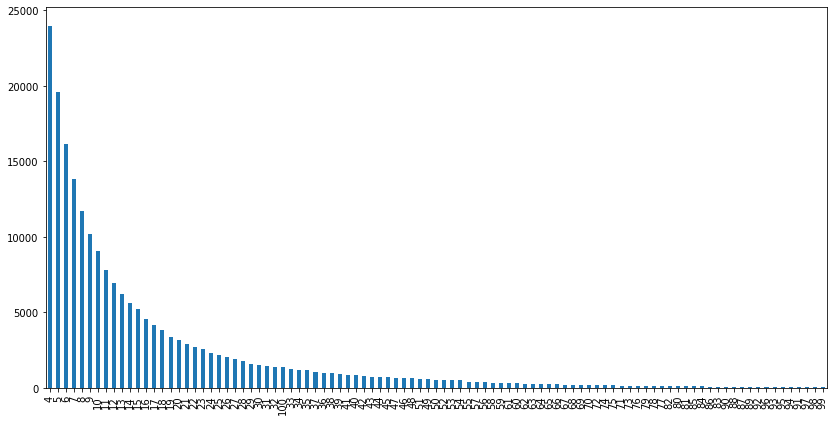

In [ ]:
plt.figure(figsize=(14, 7))
orders.groupby('user_id')['order_number'].max().value_counts().plot.bar()
plt.show()

So there are no orders less than 4 and is max capped at 100 as given in the data page. 

Now let us see how the ordering habit changes with day of week.

4번 주문한 유저가 가장 많다. 

In [ ]:
data = orders.groupby('user_id')['order_number'].max().value_counts().reset_index()
data[data['index'] < 39]['order_number'].sum() / sum(orders.groupby('user_id')['order_number'].max().value_counts())

0.9045434486370624

90% 이상 유저가 39번 미만의 주문횟수를 가지고 있다. 

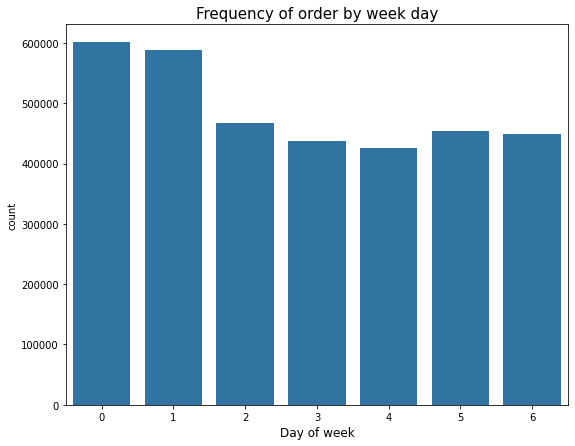

In [ ]:
plt.figure(figsize=(9, 7))
sns.countplot(x='order_dow', data=orders, color=color[0])
plt.title("Frequency of order by week day", fontsize=15)
plt.xlabel('Day of week', fontsize=12)
plt.show()

Seems like 0 and 1 are Saturday and Sunday when the orders are high and low during Wednesday. 

토요일과 일요일에 주문이 가장 많고 평일은 비슷하지만 수요일이 가장 낮다.

Now we shall see how the distribution is with respect to time of the day.

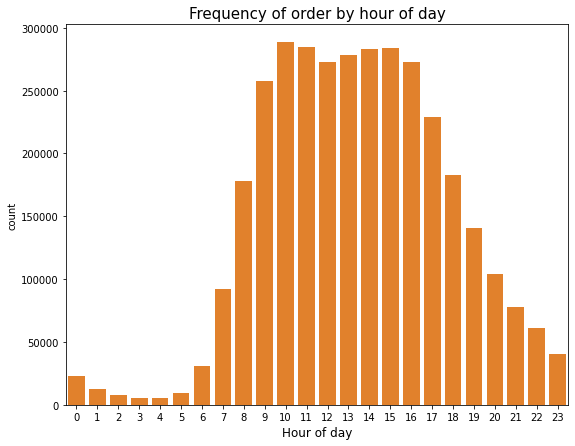

In [ ]:
plt.figure(figsize=(9, 7))
sns.countplot(x='order_hour_of_day', data=orders, color=color[1])
plt.title("Frequency of order by hour of day", fontsize=15)
plt.xlabel('Hour of day', fontsize=12)
plt.show()

So majority of the orders are made during day time. Now let us combine the day of week and hour of day to see the distribution.

대부분 낮시간에 주문을 한다.

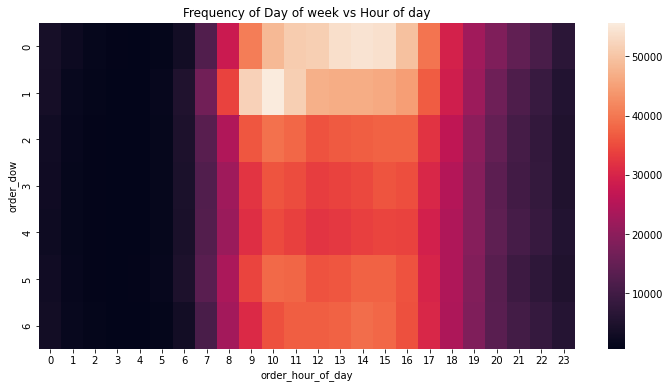

In [ ]:
grouped_df = orders.groupby(['order_dow', 'order_hour_of_day'])['order_number'].count().reset_index()
grouped_df = grouped_df.pivot('order_dow', 'order_hour_of_day', 'order_number')
plt.figure(figsize=(12, 6))
sns.heatmap(grouped_df)
plt.title('Frequency of Day of week vs Hour of day')
plt.show()

Seems Saturday evenings and Sunday mornings are the prime for orders.

Now let us check the time interval between the orders.

요일과 시간을 보면 주말과 평일의 주문횟수가 확연히 차이난다. 주말의 경우 토요일은 오후, 일요일은 오전에 주문이 가장 많다. 평일은 쏠리는 시간대가 없이 고르다. 


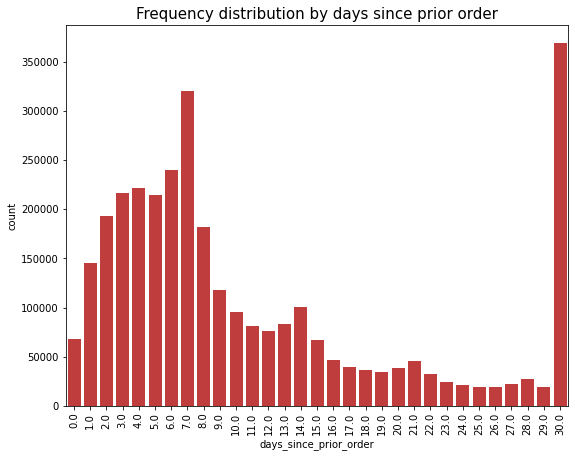

In [ ]:
plt.figure(figsize=(9,7))
sns.countplot(x='days_since_prior_order', data=orders, color=color[3])
plt.xticks(rotation='vertical')
plt.title("Frequency distribution by days since prior order", fontsize=15)
plt.show()

Looks like customers order once in every week (check the peak at 7 days) or once in a month (peak at 30 days). We could also see smaller peaks at 14, 21 and 28 days (weekly intervals).

Since our objective is to figure out the re-orders, let us check out the re-order percentage in prior set and train set.

주문 간격이 하루부터 7일까지 계속 늘다가 7일에 정점을 찍는다. 그리고 29일까지 줄기만 한다. 14일과 21일, 28일에 잠깐씩 주문이 증가하는게 보인다. 30일 이상 간격의 주문이 가장 많다. 

In [ ]:
order_products_prior.head(10)

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0
5,2,17794,6,1
6,2,40141,7,1
7,2,1819,8,1
8,2,43668,9,0
9,3,33754,1,1


In [ ]:
# percentage of re-orders in prior set
order_products_prior['reordered'].sum() / order_products_prior.shape[0]

0.5896974667922161

In [ ]:
# percentage of re-orders in train set
order_products_train['reordered'].sum() / order_products_train.shape[0]

0.5985944127509629

On an average, about 59% of the products in an order are re-ordered products. 

59%의 제품이 재주문된다. 

**No re-ordered products:**

Now that we have seen 59% of the products are re-ordered, there will also be situations when none of the products are re-ordered. Let us check that now.



In [ ]:
grouped_df = order_products_prior.groupby('order_id')['reordered'].sum().reset_index()
grouped_df.head()

,order_id,reordered
0,2,6
1,3,8
2,4,12
3,5,21
4,6,0


In [ ]:
grouped_df[grouped_df['reordered'] > 1] = 1
grouped_df['reordered'].value_counts() / grouped_df.shape[0]

1    0.879151
0    0.120849
Name: reordered, dtype: float64

In [ ]:
grouped_df = order_products_train.groupby('order_id')['reordered'].sum().reset_index()
grouped_df[grouped_df['reordered'] > 1] = 1
grouped_df['reordered'].value_counts() / grouped_df.shape[0]

1    0.93444
0    0.06556
Name: reordered, dtype: float64

About 12% of the orders in prior set has no re-ordered items while in the train set it is 6.5%.

평균적으로 한 번의 주문에 88%의 제품은 재주문 제품이다. 가장 마지막 주문인 train set에서는 93% 제품이 재주문 제품이다.

생각보다 재주문 제품의 비율이 엄청 높다. 새로운 재품을 사게 만드는 게 정말 어려운 일이라는 생각이든다. 

더 많은 데이터가 있는 prior셋에서 좀 더 일반적인 평균 수치일 가능성이 높아보인다. 검증하기 위해서는 prior셋에서 가장 마지막 order를 뽑아서 평균을 내본다.

orders에서 각 user_id 마다 가장 큰 order_number-1의 order_id를 추출하면 된다.
(시도했으나 실패)


In [ ]:
orders

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0
...,...,...,...,...,...,...,...
3421078,2266710,206209,prior,10,5,18,29.0
3421079,1854736,206209,prior,11,4,10,30.0
3421080,626363,206209,prior,12,1,12,18.0
3421081,2977660,206209,prior,13,1,12,7.0


Now let us see the number of products bought in each order.

### 주문당 제품 개수 분포

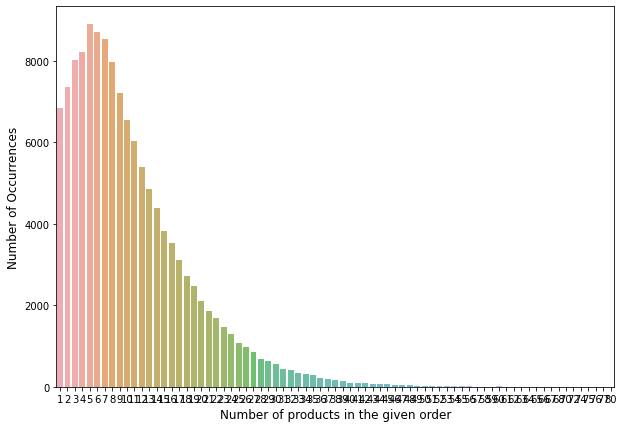

In [ ]:
grouped_df = order_products_train.groupby('order_id')['add_to_cart_order'].max().reset_index()
cnt_srs = grouped_df['add_to_cart_order'].value_counts()

plt.figure(figsize=(10, 7))
sns.barplot(cnt_srs.index, cnt_srs.values, alpha=0.8)
plt.ylabel('Number of Occurrences', fontsize=12)
plt.xlabel('Number of products in the given order', fontsize=12)
plt.show()

A right tailed distribution with the maximum value at 5.!

Before we explore the product details, let us look at the other three files as well.

Now let us merge these product details with the order_prior details.

In [ ]:
products.head()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [ ]:
order_products_prior.head()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [ ]:
aisles

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation
...,...,...
129,130,hot cereal pancake mixes
130,131,dry pasta
131,132,beauty
132,133,muscles joints pain relief


In [ ]:
order_products_prior_df = pd.merge(order_products_prior, products, on='product_id', how='left')
order_products_prior_df = pd.merge(order_products_prior_df, aisles, on='aisle_id', how='left')
order_products_prior_df = pd.merge(order_products_prior_df, departments, on='department_id', how='left')
order_products_prior_df.head()

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,Natural Sweetener,17,13,baking ingredients,pantry


### 상품별 주문 판매수

In [ ]:
cnt_srs = order_products_prior_df['product_name'].value_counts().reset_index().head(20)
cnt_srs.columns = ['product_name','frequency_count']
cnt_srs

,product_name,frequency_count
0,Banana,472565
1,Bag of Organic Bananas,379450
2,Organic Strawberries,264683
3,Organic Baby Spinach,241921
4,Organic Hass Avocado,213584
5,Organic Avocado,176815
6,Large Lemon,152657
7,Strawberries,142951
8,Limes,140627
9,Organic Whole Milk,137905


Wow. Most of them are organic products! Also majority of them are fruits.

바나나가 가장 판매량이 높다. 유기농 제품의 상품 판매량이 정말 높다. 판매량이 높은 대부분의 제품은 채소와 과일이다. 

Now let us look at the important aisles.

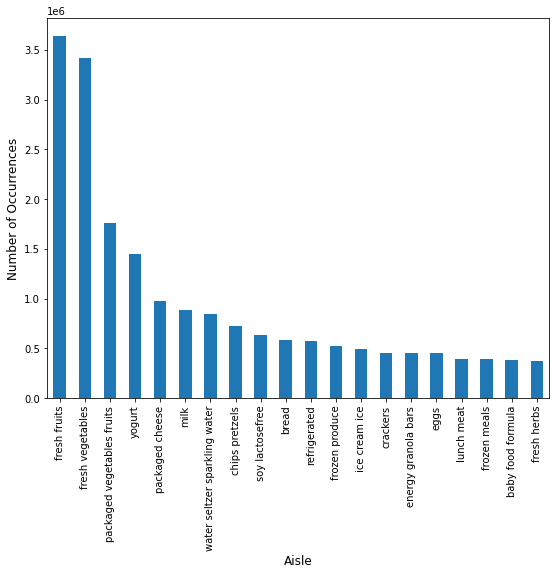

In [ ]:
plt.figure(figsize=(9,7))
order_products_prior_df['aisle'].value_counts().head(20).plot.bar()
plt.ylabel('Number of Occurrences', fontsize=12)
plt.xlabel('Aisle', fontsize=12)
plt.show()

The top two aisles are fresh fruits and fresh vegetables! 

채소와 과일의 판매량이 가장 높다.

### Department Distribution:

Let us now check the department wise distribution.

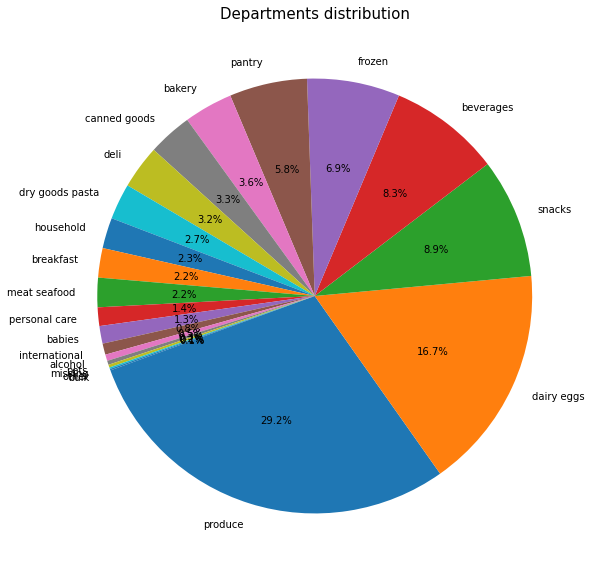

In [ ]:
plt.figure(figsize=(10,10))
temp_series = order_products_prior_df['department'].value_counts()
labels = (np.array(temp_series.index))
sizes = (np.array((temp_series / temp_series.sum())*100))
plt.pie(sizes, labels=labels, autopct='%1.1f%%',startangle=200)
plt.title('Departments distribution', fontsize=15)
plt.show()

Produce is the largest department. 

위와 마찬가지로 농작물의 판매량이 가장 높다.

Now let us check the reordered percentage of each department.

### Department wise reorder ratio:

/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


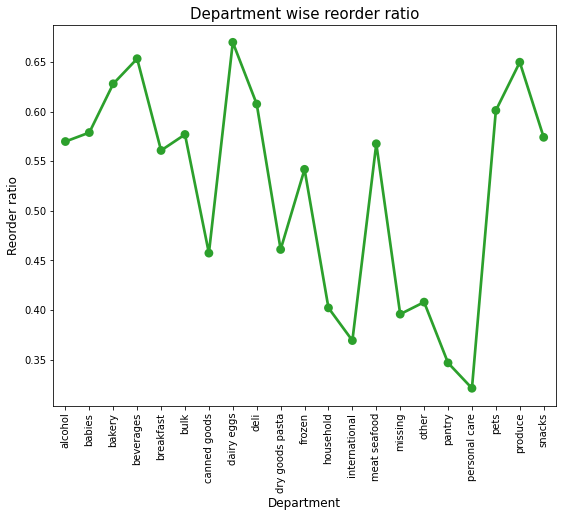

In [ ]:
grouped_df = order_products_prior_df.groupby(['department'])['reordered'].mean().reset_index()

plt.figure(figsize=(9, 7))
sns.pointplot(grouped_df['department'].values, grouped_df['reordered'].values, alpha=0.8, color=color[2])
plt.ylabel('Reorder ratio', fontsize=12)
plt.xlabel('Department', fontsize=12)
plt.title("Department wise reorder ratio", fontsize=15)
plt.xticks(rotation='vertical')
plt.show()

Personal care has lowest reorder ratio and dairy eggs have highest reorder ratio.

personal care 제품의 재주문률이 가장 낮다. 계란&유제품의 재주문률이 가장 높다.


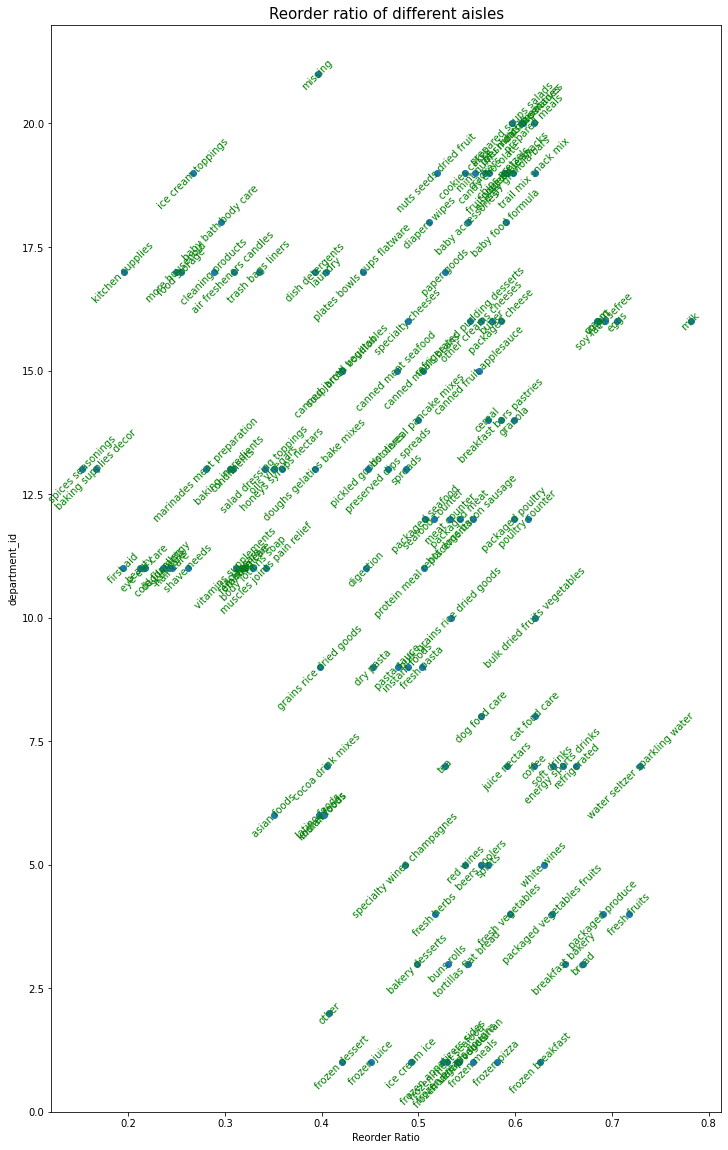

In [ ]:
grouped = order_products_prior_df.groupby(['department_id', 'aisle'])['reordered'].mean().reset_index()

f,ax = plt.subplots(figsize=(12, 20))
ax.scatter(grouped['reordered'].values, grouped['department_id'].values)
for i, txt in enumerate(grouped['aisle'].values):
    ax.annotate(txt, (grouped['reordered'].values[i], grouped['department_id'].values[i]), 
                rotation=45, ha='center', va='center', color='green')
plt.xlabel('Reorder Ratio')
plt.ylabel('department_id')
plt.title('Reorder ratio of different aisles', fontsize=15)
plt.show()

### Add to Cart - Reorder ratio:

Let us now explore the relationship between how order of adding the product to the cart affects the reorder ratio.

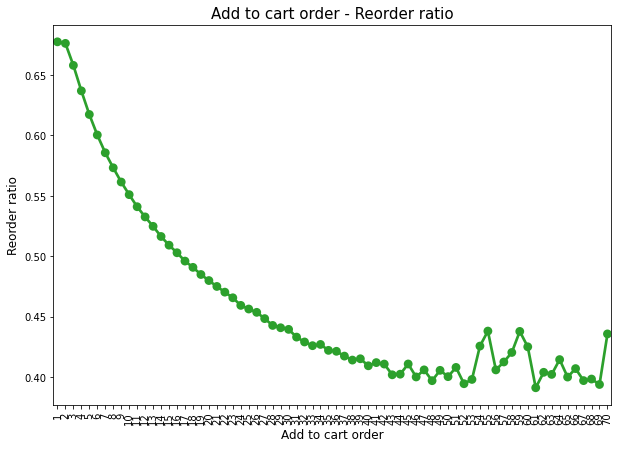

In [ ]:
order_products_prior_df['add_to_cart_order_mod'] = order_products_prior_df['add_to_cart_order'].copy()
order_products_prior_df['add_to_cart_order_mod'][order_products_prior_df['add_to_cart_order_mod'] > 70] = 70
grouped = order_products_prior_df.groupby('add_to_cart_order_mod')['reordered'].mean().reset_index()

plt.figure(figsize=(10, 7))
sns.pointplot(grouped['add_to_cart_order_mod'].values, 
              grouped['reordered'].values, 
              alpha=0.8, color=color[2])
plt.ylabel('Reorder ratio', fontsize=12)
plt.xlabel('Add to cart order', fontsize=12)
plt.title("Add to cart order - Reorder ratio", fontsize=15)
plt.xticks(rotation='vertical')
plt.show()

**Looks like the products that are added to the cart initially are more likely to be reordered again compared to the ones added later.** This makes sense to me as well since we tent to first order all the products we used to buy frequently and then look out for the new products avaiable.

장바구니에 담긴 순서에 따라 재구매율이 정말 정직하게 낮아진다. 장바구니에 담긴 순서가 이를 수록 재주문률이 높다고 확실하게 말할 수 있다.

### Reorder ratio by Time based variables:

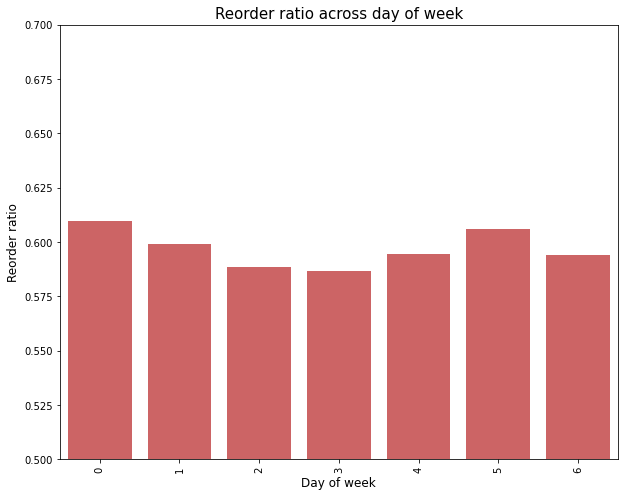

In [ ]:
order_products_train_df = pd.merge(order_products_train, 
                                   orders, 
                                   on='order_id', 
                                   how='left')
grouped = order_products_train_df.groupby('order_dow')['reordered'].mean().reset_index()

plt.figure(figsize=(10, 8))
sns.barplot(grouped['order_dow'].values, grouped['reordered'].values, alpha=0.8, color=color[3])
plt.ylabel('Reorder ratio', fontsize=12)
plt.xlabel('Day of week', fontsize=12)
plt.title("Reorder ratio across day of week", fontsize=15)
plt.xticks(rotation='vertical')
plt.ylim(0.5, 0.7)
plt.show()

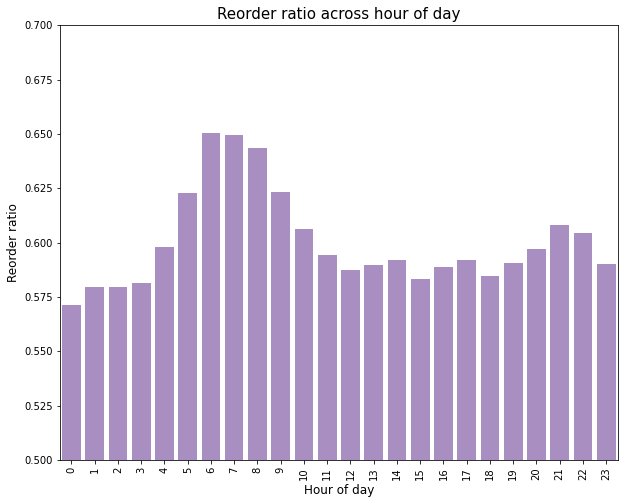

In [ ]:
grouped = order_products_train_df.groupby('order_hour_of_day')['reordered'].mean().reset_index()

plt.figure(figsize=(10, 8))
sns.barplot(grouped['order_hour_of_day'].values, grouped['reordered'].values, alpha=0.8, color=color[4])
plt.ylabel('Reorder ratio', fontsize=12)
plt.xlabel('Hour of day', fontsize=12)
plt.title("Reorder ratio across hour of day", fontsize=15)
plt.xticks(rotation='vertical')
plt.ylim(0.5, 0.7)
plt.show()

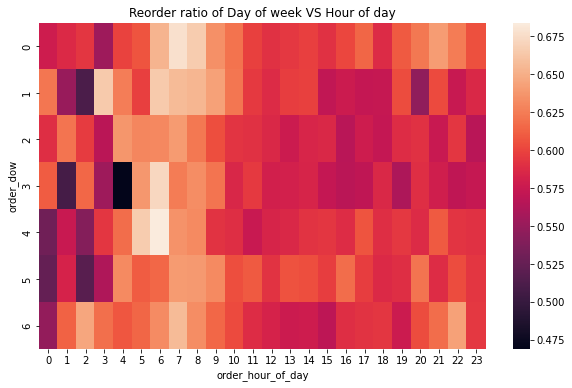

In [ ]:
grouped = order_products_train_df.groupby(['order_dow', 'order_hour_of_day'])['reordered'].mean().reset_index()
grouped = grouped.pivot('order_dow','order_hour_of_day','reordered')

plt.figure(figsize=(10, 6))
sns.heatmap(grouped)
plt.title('Reorder ratio of Day of week VS Hour of day')
plt.show()